---
title: "Practice Activity 6.2: Multiple Regression and Model Validation"author: Lily
format:
    html:
        embed-resources: true
        code-line-numbers: true
---

**GitHub Repository**: <https://github.com/lilysteinberg/GSB-544---Computing-and-ML/tree/main/Week%205>

# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [115]:
### General libraries (more added throughout the code as necessary from sklearn and plotnine)
import numpy as np
import pandas as pd

### Penguin data
!pip install palmerpenguins
from palmerpenguins import load_penguins

In [116]:
# set up penguins df
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [117]:
### Making dummies
penguins = pd.get_dummies(penguins, drop_first = True)
# this math converts bools to numbers
penguins = penguins * 1
# visual confirmation of data
penguins.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_male
0,39.1,18.7,181.0,3750.0,2007,0,0,0,1,1
1,39.5,17.4,186.0,3800.0,2007,0,0,0,1,0
2,40.3,18.0,195.0,3250.0,2007,0,0,0,1,0
3,NaN,NaN,NaN,NaN,2007,0,0,0,1,0
4,36.7,19.3,193.0,3450.0,2007,0,0,0,1,0


Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on a training dataset subset of the entire dataset:

* Four different models, each containing a different set of predictor variables

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

# Data Partitioning

In [118]:
# omission strategy for missing data (required to get code to work)
penguins = penguins.dropna()

In [119]:
from sklearn.model_selection import train_test_split

### data partitioning
X_train, X_test, y_train, y_test = train_test_split(penguins.drop(['bill_depth_mm'], axis=1), penguins[['bill_depth_mm']], test_size=0.25)
# 0.25 (25%) are in the validaiton set

# Model 1

In [120]:
from sklearn.linear_model import LinearRegression

### Model 1 - fitting model
model1 = LinearRegression()
model1.fit(
    X=X_train[["bill_length_mm"]],
    y=y_train
)

LinearRegression()

In [121]:
### Model 1 - predictions
y_test_ = model1.predict(X=X_test[["bill_length_mm"]])
# add prediction to X_test dataframe as new columm
X_test["model1"] = y_test_

#X_test

# Model 2

In [122]:
### Model 2 -- fitting model
model2 = LinearRegression()
model2.fit(
    X=X_train[["bill_length_mm", "body_mass_g"]],
    y=y_train
)

LinearRegression()

In [123]:
### Model 2 - predictions
y_test_ = model2.predict(X=X_test[["bill_length_mm", "body_mass_g"]])
# add prediction to X_test dataframe as new columm
X_test["model2"] = y_test_

#X_test

# Model 3

In [124]:
### Model 3 -- fitting model
model3 = LinearRegression()
model3.fit(
    X=X_train[["bill_length_mm", "body_mass_g", "flipper_length_mm"]],
    y=y_train
)

LinearRegression()

In [125]:
### Model 3 -- predictions
y_test_ = model3.predict(X=X_test[["bill_length_mm", "body_mass_g", "flipper_length_mm"]])
# add prediction to X_test dataframe as new columm
X_test["model3"] = y_test_

#X_test

# Model 4

In [127]:
### Model 4 -- fitting model
model4 = LinearRegression()
model4.fit(
    X=X_train[["bill_length_mm", "body_mass_g", "flipper_length_mm", "species_Chinstrap",	"species_Gentoo"]],
    y=y_train
)

LinearRegression()

In [128]:
### Model 4 -- predictions
y_test_ = model4.predict(X=X_test[["bill_length_mm", "body_mass_g", "flipper_length_mm", "species_Chinstrap",	"species_Gentoo"]])
# add prediction to X_test dataframe as new columm
X_test["model4"] = y_test_

#X_test

# Model Evaluation

In [129]:
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Model 1": ["bill_length_mm"],
    "Model 2": ["bill_length_mm", "body_mass_g"],
    "Model 3": ["bill_length_mm", "body_mass_g", "flipper_length_mm"],
    "Model 4": ["bill_length_mm", "body_mass_g", "flipper_length_mm",	"species_Chinstrap",	"species_Gentoo"],
}


### Loop to calculate RMSE and R2 from TRAINING data

rows = []
for name, Xcols in models.items():
    ##### TRAINING DATA
    # go thru list of models pulling data from X_train
    X = X_train[Xcols]
    # fit model based on columns in model list above
    model = LinearRegression().fit(X, y_train)
    # make predictions
    y_train_ = model.predict(X_train[Xcols])
    # save it
    X_train[f"{name}_predict"] = y_train_
    # calculate MSE
    train_mse = mean_squared_error(y_train, y_train_)
    # calculate r-squared
    train_r2 = r2_score(y_train, y_train_)
    # save data to df
    rows.append({"Model": name, "Train RMSE": train_mse, "Train R2": train_r2})

train_error = pd.DataFrame(rows)
train_error

,Model,Train RMSE,Train R2
0,Model 1,3.577335,0.060223
1,Model 2,2.993728,0.213539
2,Model 3,2.406093,0.367912
3,Model 4,0.659676,0.826701


In [130]:
### Loop to calculate RMSE and R2 from TEST data

rows = []
for name, Xcols in models.items():
    # go thru list of models pulling data from X_train
    X = X_train[Xcols]
    # fit model based on columns in model list
    model = LinearRegression().fit(X, y_train)
    # make predictions
    y_test_ = model.predict(X_test[Xcols])
    # save it
    X_test[f"{name}_predict"] = y_test_
    # calculate MSE
    test_mse = mean_squared_error(y_test, y_test_)
    # calculate r-squared
    test_r2 = r2_score(y_test, y_test_)
    # save data to df
    rows.append({"Model": name, "Test RMSE": test_mse, "Test R2": test_r2})

test_error = pd.DataFrame(rows)
test_error

,Model,Test RMSE,Test R2
0,Model 1,3.970511,0.033874
1,Model 2,3.068235,0.253421
2,Model 3,2.385664,0.419508
3,Model 4,0.822858,0.799778


In [131]:
### Cleaning data for plot
# merge error dfs into one df
df_error = train_error.merge(test_error, on="Model")
df_error

,Model,Train RMSE,Train R2,Test RMSE,Test R2
0,Model 1,3.577335,0.060223,3.970511,0.033874
1,Model 2,2.993728,0.213539,3.068235,0.253421
2,Model 3,2.406093,0.367912,2.385664,0.419508
3,Model 4,0.659676,0.826701,0.822858,0.799778


In [132]:
# convert to long format for graphing
df_error_long = df_error.melt(id_vars= ["Model"], value_vars = ["Train RMSE", "Test RMSE"], var_name = "type", value_name = "RMSE")
df_error_long

,Model,type,RMSE
0,Model 1,Train RMSE,3.577335
1,Model 2,Train RMSE,2.993728
2,Model 3,Train RMSE,2.406093
3,Model 4,Train RMSE,0.659676
4,Model 1,Test RMSE,3.970511
5,Model 2,Test RMSE,3.068235
6,Model 3,Test RMSE,2.385664
7,Model 4,Test RMSE,0.822858


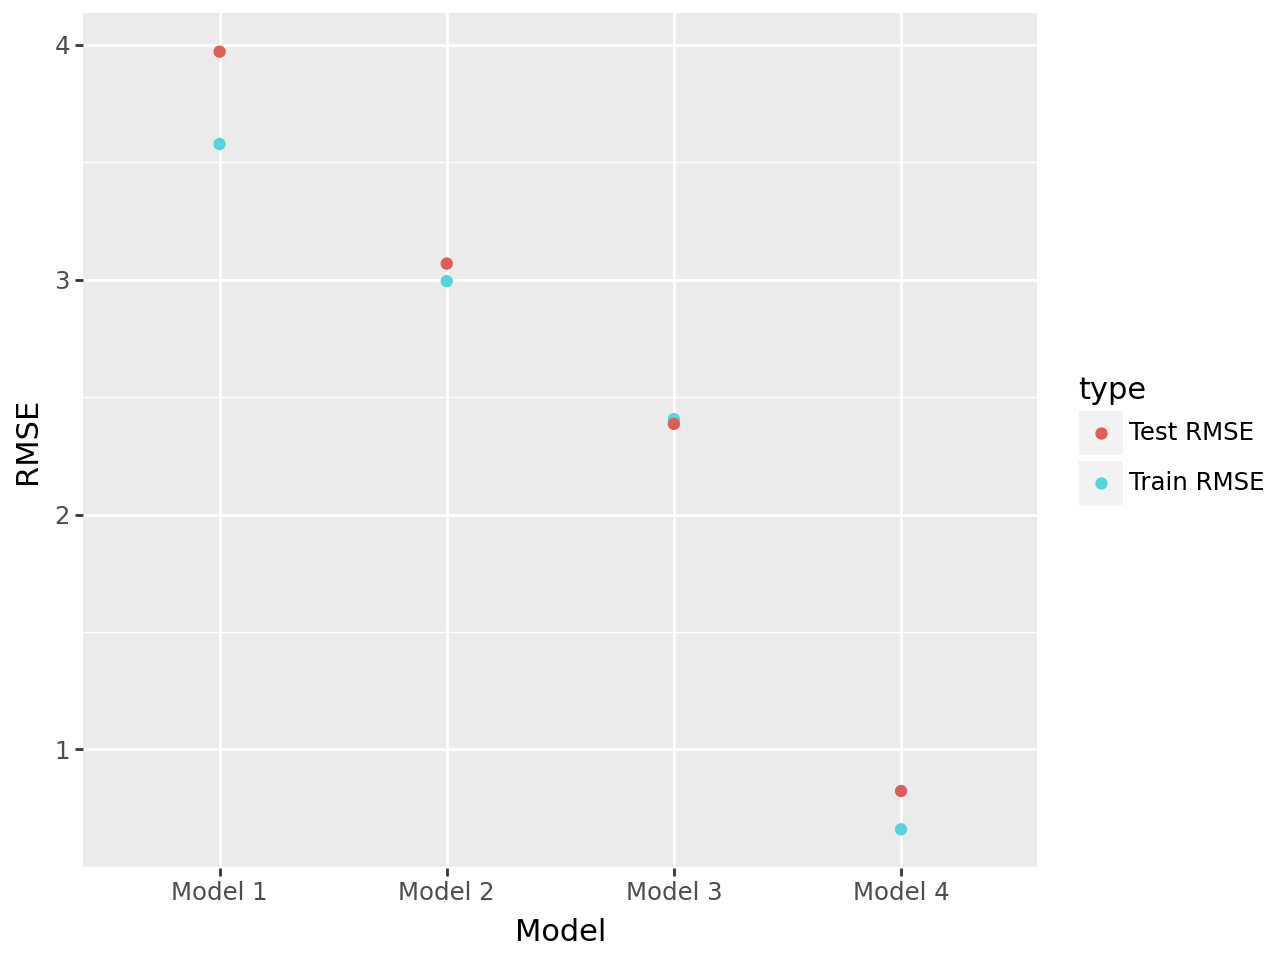

In [133]:
from plotnine import *

# graph
(ggplot(df_error_long,
        aes(x = "Model",
            y = "RMSE",
            color = "type")) +
 geom_point())

Model 4 is the best model out of the ones I tried. It has the lowest RMSE, and the test and train datasets yield similar RMSE values for Model 4, suggesting that there is not a major issue with overfitting the training dataset. This provides confidence that including all of those predictor variables does, in fact, improve predictions.